In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier

In [3]:
df = pd.read_csv("final_cleaned_dataset.csv")
df.head()

,iso3,country,disaster_type,year,deaths,affected,mng_cap,inventory,distance,priority_tier
0,28,26,13,0.838383,-0.040109,-0.065012,-0.423649,0.540336,-1.083849,2
1,209,213,30,-1.241796,-0.041592,-0.064716,1.571977,0.755815,-0.506201,1
2,168,162,13,1.358428,-0.040480,-0.065068,0.814421,-0.870840,0.849504,2
3,209,213,5,1.618450,-0.041592,-0.065068,0.352603,-1.506011,-0.688926,0
4,87,91,26,1.358428,-0.037884,-0.065064,-1.180516,-0.810281,0.766983,0


In [4]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16752 entries, 0 to 16751
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   iso3           16752 non-null  int64  
 1   country        16752 non-null  int64  
 2   disaster_type  16752 non-null  int64  
 3   year           16752 non-null  float64
 4   deaths         16752 non-null  float64
 5   affected       16752 non-null  float64
 6   mng_cap        16752 non-null  float64
 7   inventory      16752 non-null  float64
 8   distance       16752 non-null  float64
 9   priority_tier  16752 non-null  int64  
dtypes: float64(6), int64(4)
memory usage: 1.3 MB


iso3             0
country          0
disaster_type    0
year             0
deaths           0
affected         0
mng_cap          0
inventory        0
distance         0
priority_tier    0
dtype: int64

In [5]:
le_iso = LabelEncoder()
le_country = LabelEncoder()
le_disaster = LabelEncoder()
le_priority = LabelEncoder()

df['iso3'] = le_iso.fit_transform(df['iso3'])
df['country'] = le_country.fit_transform(df['country'])
df['disaster_type'] = le_disaster.fit_transform(df['disaster_type'])

df['priority_tier'] = le_priority.fit_transform(df['priority_tier'])

In [6]:
X = df.drop("priority_tier", axis=1)
y = df["priority_tier"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [8]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [9]:
y_pred = model.predict(X_test)

In [10]:
probabilities = model.predict_proba(X_test)
print(probabilities[:5])

[[9.95677991e-01 4.76190476e-04 3.84581807e-03]
 [9.90008066e-01 1.56750710e-04 9.83518352e-03]
 [2.02898551e-03 9.60129660e-01 3.78413548e-02]
 [3.43433449e-01 2.15124883e-02 6.35054062e-01]
 [1.44164664e-02 8.36075539e-01 1.49507994e-01]]


In [11]:
print(model.classes_)
print(le_priority.classes_)

[0 1 2]
[0 1 2]


In [12]:
def adjust_priority(prob):

    critical_prob = prob[0]
    low_prob = prob[1]
    moderate_prob = prob[2]

    if critical_prob > 0.85:
        return 0
    elif moderate_prob > 0.50:
        return 2
    else:
        return 1

In [13]:
adjusted_pred = [adjust_priority(p) for p in probabilities]

In [14]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
accuracy = accuracy_score(y_test, y_pred)
adjusted_acc = accuracy_score(y_test, adjusted_pred)

print("Model Accuracy:", accuracy)
print("adjusted accuracy:",adjusted_acc)

Model Accuracy: 0.9806028051327962
adjusted accuracy: 0.9203222918531782


In [16]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1083    0   20]
 [   0 1110   18]
 [  12   15 1093]]


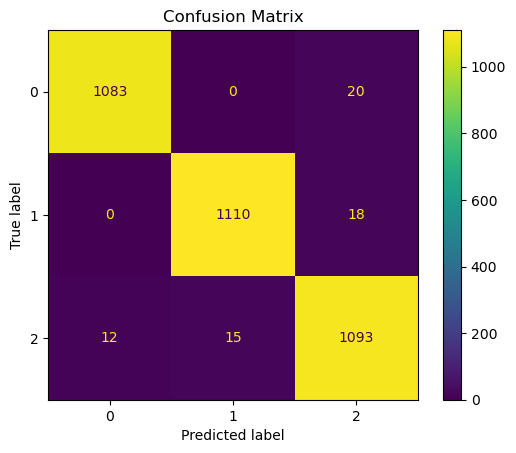

In [17]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()

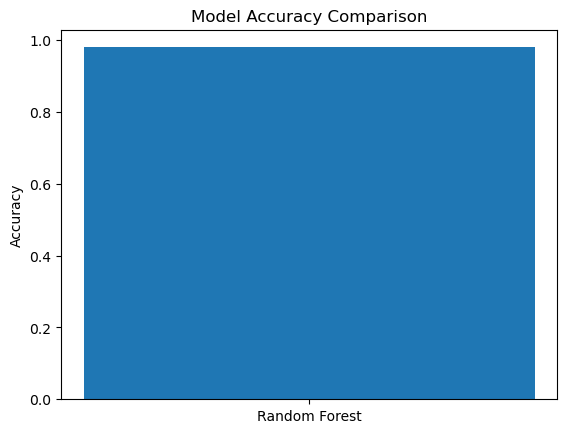

In [18]:
models = ["Random Forest"]
scores = [accuracy]

plt.bar(models, scores)

plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.show()